# Project Title: Water Potability Prediction System

 Problem Statement:
Predict whether water is safe for drinking based on its chemical properties using classification algorithms.

### Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# SMOTE
from imblearn.over_sampling import SMOTE

import joblib

Explanation:

Imports required tools for:

Data handling (pandas, numpy)

Visualization (matplotlib, seaborn)

ML models and evaluation

SMOTE for class balancing
Saving model

### Load Data

In [17]:
data = pd.read_csv("/content/water_potability.csv")

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


Explanation:
Loads dataset into DataFrame
Shape tells rows and columns
head() shows first 5 rows

### EDA- Exploratory Data Analysis

### Target Distribution

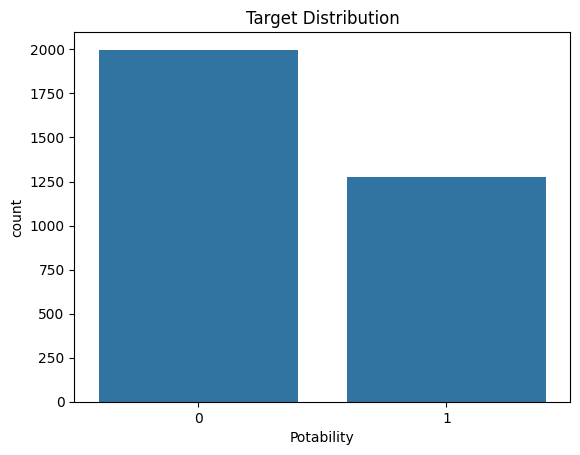

Potability
0    1998
1    1278
Name: count, dtype: int64


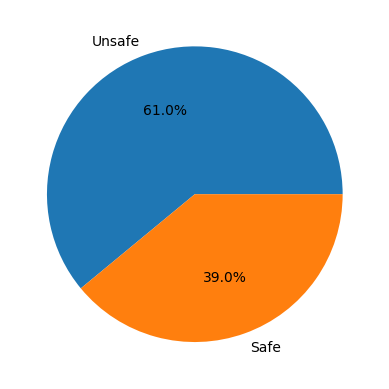

In [18]:
sns.countplot(x='Potability', data=data)
plt.title("Target Distribution")
plt.show()

print(data['Potability'].value_counts())

plt.pie(data['Potability'].value_counts(), labels=["Unsafe","Safe"], autopct="%1.1f%%")
plt.show()

Explanation:

->Shows class imbalance

-> Countplot shows count of safe (1) and unsafe (0) water.

->Pie shows percentage distribution of classes.

->Justifies use of SMOTE later

### Feature Distribution

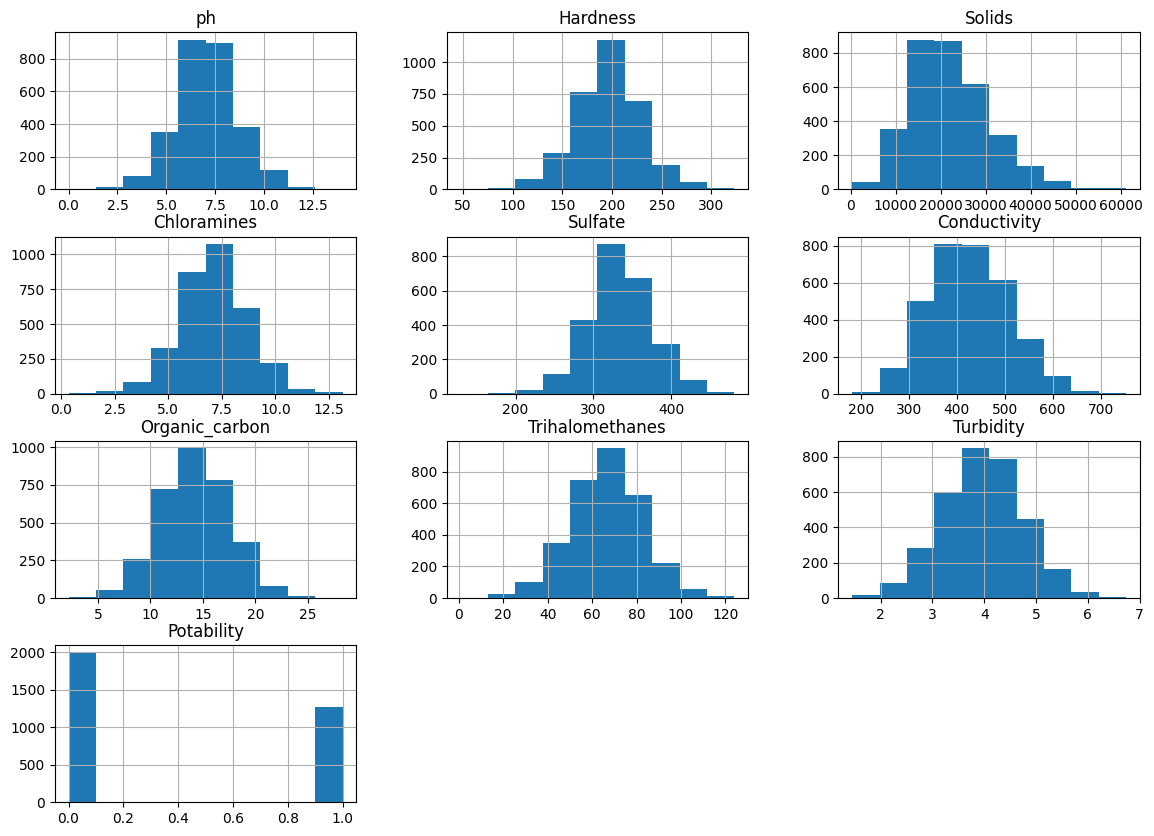

In [19]:
data.hist(figsize=(14,10))
plt.show()

Shows how each feature is distributed.

### Box Plot Outliers

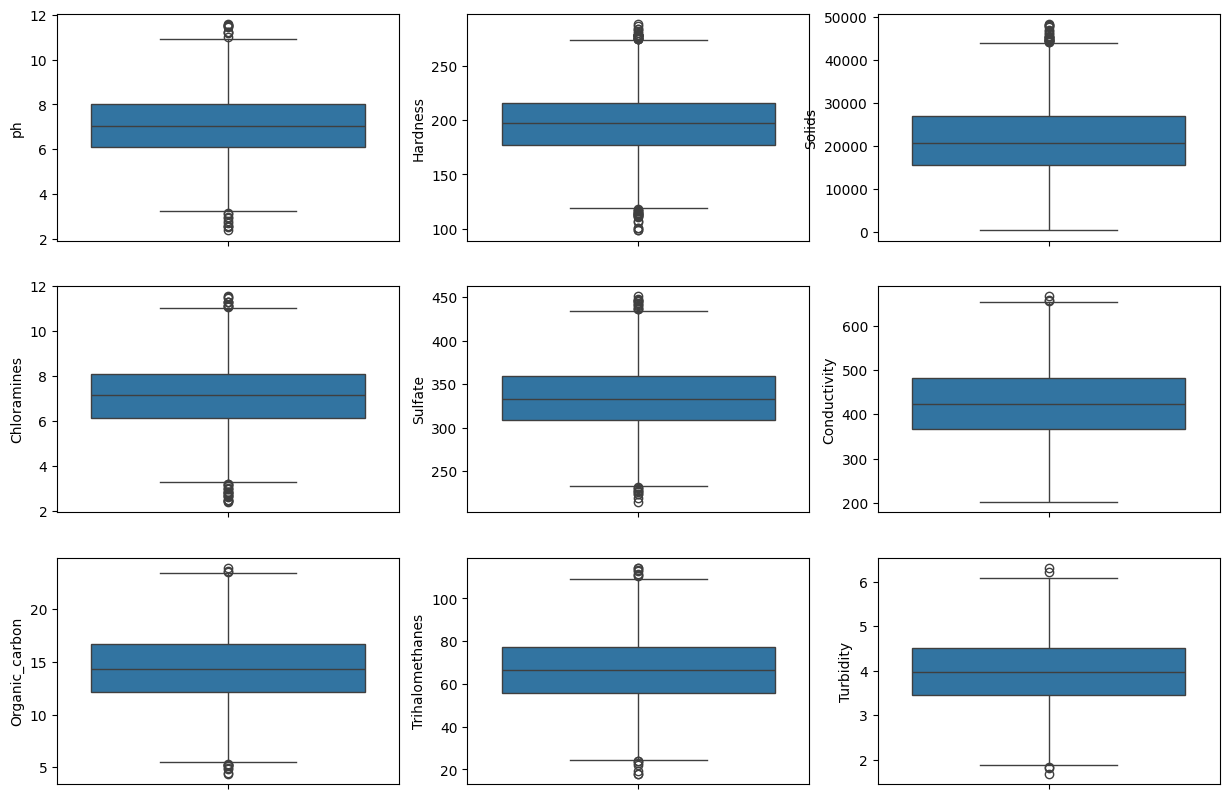

In [33]:
plt.figure(figsize=(15,10))
for i, col in enumerate(data.columns[:-1],1):
    plt.subplot(3,3,i)
    sns.boxplot(y=data[col])
plt.show()

Explanation:

Visual detection of outliers.

### Violin Plot

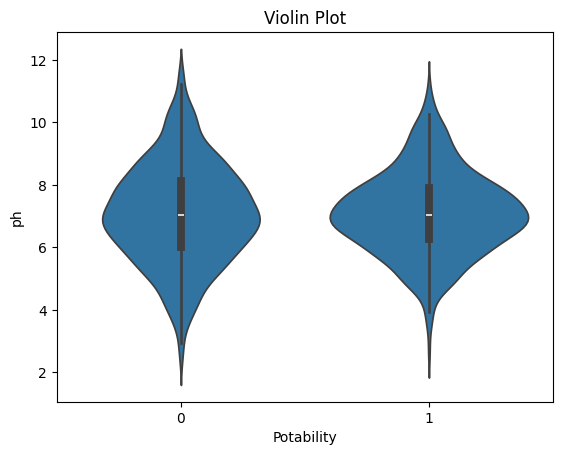

In [29]:
sns.violinplot(x="Potability", y="ph", data=data)
plt.title("Violin Plot")
plt.show()

Explanation:

Shows distribution difference between safe and unsafe water. It shows density.

## Scatter Plot

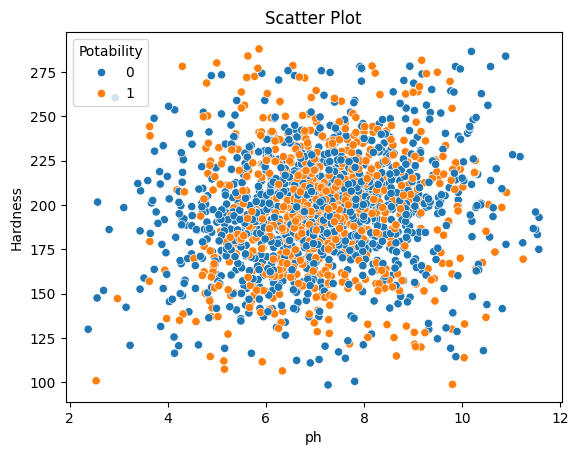

In [28]:
sns.scatterplot(x="ph", y="Hardness", hue="Potability", data=data)
plt.title("Scatter Plot")
plt.show()

Explanation:

Shows relationship between features. It shows interaction between features

### Correlation Heatmap

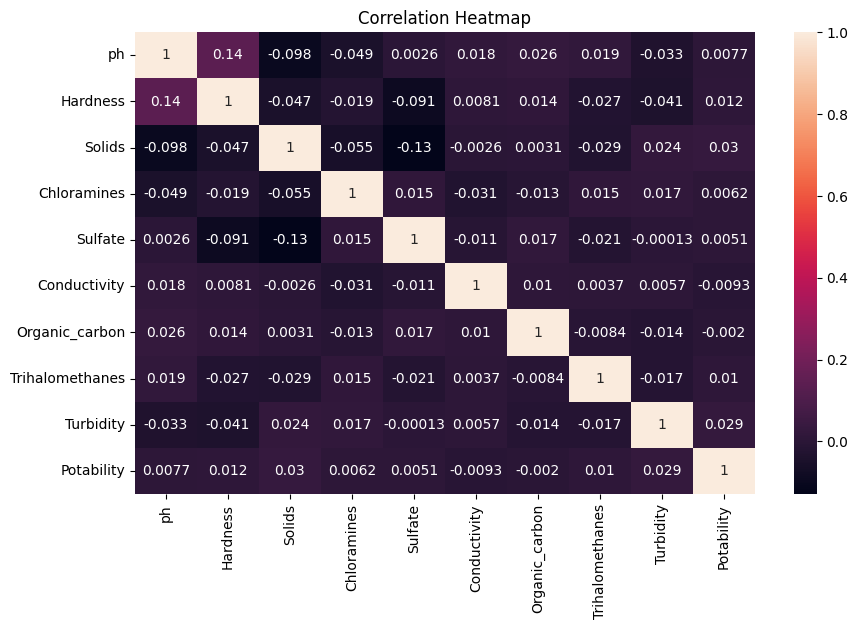

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Explanation:

Shows correlation between variables.

### Outliers (Z-score)

In [24]:
features = data.drop("Potability", axis=1)
z_scores = np.abs((features - features.mean()) / features.std())

print((z_scores > 3).sum())

ph                 16
Hardness           18
Solids             20
Chloramines        20
Sulfate            17
Conductivity        7
Organic_carbon      4
Trihalomethanes    12
Turbidity           8
dtype: int64


Explanation:

Detects extreme values using Z-score. Better than visual methods because it gives exact calculation

### Outliers (IQR Method)

In [25]:
for col in features.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(col, ((data[col] < lower) | (data[col] > upper)).sum())

ph 46
Hardness 83
Solids 47
Chloramines 61
Sulfate 41
Conductivity 11
Organic_carbon 25
Trihalomethanes 33
Turbidity 19


Explanation:

Another method to detect outliers using quartiles.

More robust than Z-score for skewed data

### Data Cleaning

### Removal of Outliers

In [26]:
data = data[(z_scores < 3).all(axis=1)]

Explanation:

To remove noise from dataset.

Removes extreme rows from dataset using z-score.

Improves model performance

###Dataset Understanding

In [34]:
print("\nDataset Info:\n")
data.info()

print("\nMissing Values:\n")
print(data.isnull().sum())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
Index: 1936 entries, 3 to 3271
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               1936 non-null   float64
 1   Hardness         1936 non-null   float64
 2   Solids           1936 non-null   float64
 3   Chloramines      1936 non-null   float64
 4   Sulfate          1936 non-null   float64
 5   Conductivity     1936 non-null   float64
 6   Organic_carbon   1936 non-null   float64
 7   Trihalomethanes  1936 non-null   float64
 8   Turbidity        1936 non-null   float64
 9   Potability       1936 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 166.4 KB

Missing Values:

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


Explanation:
Understanding the data by getting its info and looking for missing values in the data

In [35]:
data.fillna(data.mean(numeric_only=True), inplace=True)

Explanation:
Filling the missing values with mean.

### Data Preparation

In [40]:
x = data.drop("Potability", axis=1)
y = data["Potability"]

###Class Balancing

In [87]:
smote = SMOTE(random_state=42)
x_smote, y_smote = smote.fit_resample(x, y)
print(pd.Series(y_smote).value_counts())

Potability
0    1170
1    1170
Name: count, dtype: int64


Explanation:

Using SMOTE for balancing the class. It balances dataset by generating synthetic data.

It is better than oversampling because it creates new synthetic data.

We get Equal class distribution and Less bias

### Before and After SMOTE

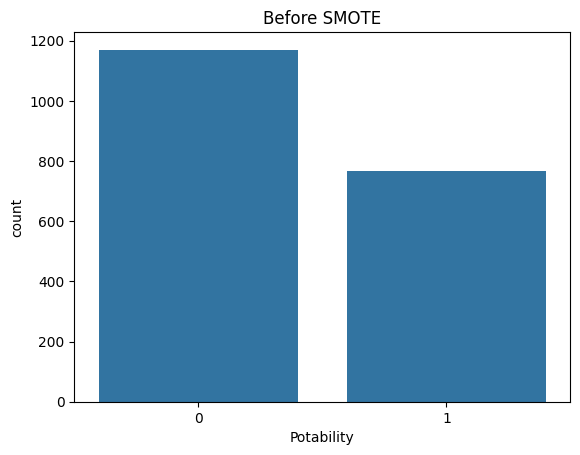

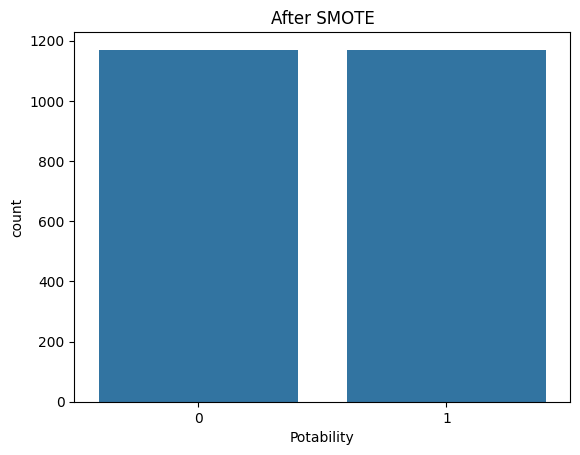

In [42]:
sns.countplot(x=y)
plt.title("Before SMOTE")
plt.show()

sns.countplot(x=y_smote)
plt.title("After SMOTE")
plt.show()

### Train Test Split

In [43]:
x_train, x_test, y_train, y_test = train_test_split(
    x_smote, y_smote, test_size=0.2, random_state=42)

To test model performance.

It prevents overfitting

### Scaling

In [44]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

It is used to normalize features.

It is important for KNN & SVM

MinMax Scaler scales all features between 0 and 1, which works well with distance-based algorithms like KNN and SVM. It preserves the original distribution and is easy to interpret.

### Model Evaluation

In [91]:
print("Training models on balanced dataset.")

Training models on balanced dataset.


In [94]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)}

results = []

print("\nMODEL PERFORMANCE:\n")

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"--- {name} ---")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}\n")


MODEL PERFORMANCE:

--- Logistic Regression ---
Accuracy: 50.43%
Precision: 0.5217
Recall: 0.4959
F1-Score: 0.5085

--- Decision Tree ---
Accuracy: 62.18%
Precision: 0.6407
Recall: 0.6116
F1-Score: 0.6258

--- Random Forest ---
Accuracy: 67.95%
Precision: 0.6901
Recall: 0.6901
F1-Score: 0.6901

--- KNN ---
Accuracy: 63.25%
Precision: 0.6483
Recall: 0.6322
F1-Score: 0.6402

--- SVM ---
Accuracy: 65.81%
Precision: 0.6602
Recall: 0.6983
F1-Score: 0.6787



###Convert to DataFrame

In [95]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1"])

print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.504274   0.521739  0.495868  0.508475
1        Decision Tree  0.621795   0.640693  0.611570  0.625793
2        Random Forest  0.679487   0.690083  0.690083  0.690083
3                  KNN  0.632479   0.648305  0.632231  0.640167
4                  SVM  0.658120   0.660156  0.698347  0.678715


Explanation:
1.Models

1.LOGISTIC REGRESSION: It is a baseline classification model. It is used because it is simple and interpretable

2.DECISION TREE: It is rule-based model and is easy to understand.

3.RANDOM FOREST: It is used to improve accuracy. It reduces overfitting (ensemble). It gives better generalization

4.KNN: It is a distance-based model and works well with scaled data. It is a prediction based on neighbors.

5.SVM: It is used to find optimal boundary.It works well for complex data and gives maximum margin separation

ACCURACY: Is to measure overall performance. It gives % (percentage) of correct predictions.

PRECISION:Is used to check correctness of positive predictions.It shows how many predicted safe are actually safe.

RECALL:It is to check detection ability. It shows how many actual safe detected

F1 SCORE: I sued to balance precision & recall. It shows overall model performance.

### Model Comparison Graph

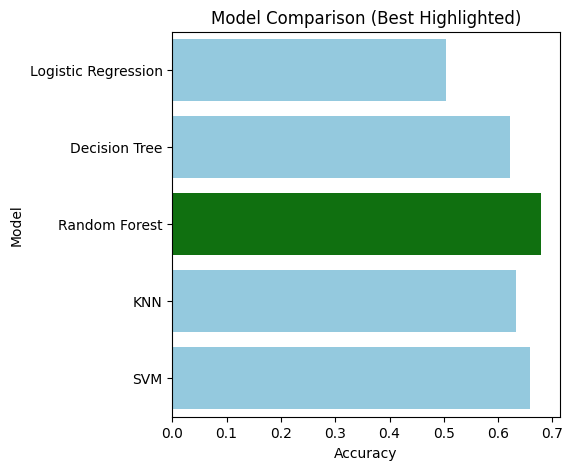

In [96]:
best_model_name = results_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"]

colors = []

for model in results_df["Model"]:
    if model == best_model_name:
        colors.append("green")  # highlight best
    else:
        colors.append("skyblue")

plt.figure(figsize=(5,5))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette=colors)

plt.title("Model Comparison (Best Highlighted)")
plt.xlabel("Accuracy")
plt.show()

### ROC Curve

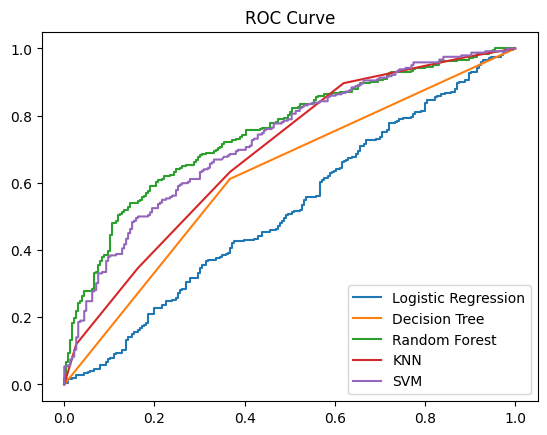

In [97]:
for name, model in models.items():
    model.fit(x_train, y_train)
    prob = model.predict_proba(x_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Curve")
plt.show()

ROC Curve is used To evaluate model across thresholds. It is better than accuracy for classification. It shows performance trade-off

###Best Model Selection

In [98]:
best_model = RandomForestClassifier()
best_model.fit(x_train, y_train)

RandomForestClassifier()

###Classification Report with Confusion Matrix

In [99]:
from sklearn.metrics import classification_report, confusion_matrix

# Train best model again
best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42)
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.67      0.67       226
           1       0.69      0.69      0.69       242

    accuracy                           0.68       468
   macro avg       0.68      0.68      0.68       468
weighted avg       0.68      0.68      0.68       468


Confusion Matrix:

[[151  75]
 [ 75 167]]


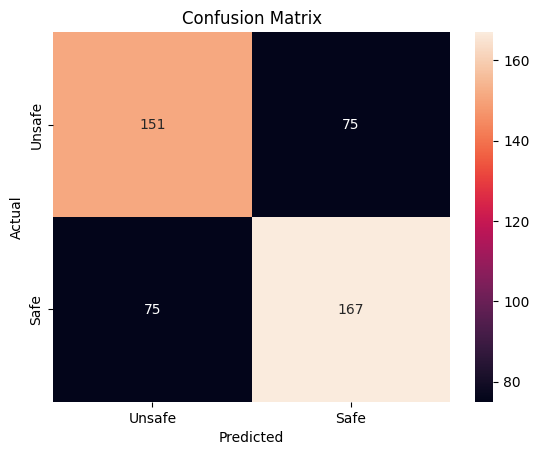

In [100]:
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d',
            xticklabels=["Unsafe","Safe"],
            yticklabels=["Unsafe","Safe"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Confusion Matrix is used to analyze prediction errors.

### Feature Importance

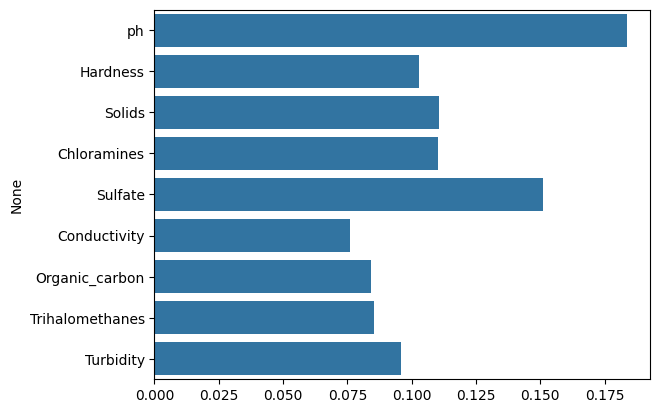

In [101]:
importance = best_model.feature_importances_

sns.barplot(x=importance, y=x.columns)
plt.show()

Explanation: To identify important features. It gives feature ranking.

###Unique Feature

In [102]:
# Initialize flags
safe_found = False
unsafe_found = False

for i in range(len(x_test)):
    sample = x_test[i].reshape(1, -1)
    pred = best_model.predict(sample)[0]
    prob = best_model.predict_proba(sample)[0]

    # SAFE CASE
    if pred == 1 and not safe_found:
        print("\nSAFE SAMPLE RESULT:")
        print("Water is SAFE for drinking ✅")
        print(f"Confidence: {round(max(prob)*100,2)}%")
        safe_found = True

    # UNSAFE CASE
    if pred == 0 and not unsafe_found:
        print("\nUNSAFE SAMPLE RESULT:")
        print("Water is NOT SAFE ❌")
        print(f"Confidence: {round(max(prob)*100,2)}%")
        unsafe_found = True

    # Stop when both found
    if safe_found and unsafe_found:
        break


UNSAFE SAMPLE RESULT:
Water is NOT SAFE ❌
Confidence: 64.48%

SAFE SAMPLE RESULT:
Water is SAFE for drinking ✅
Confidence: 78.08%


### Visualization

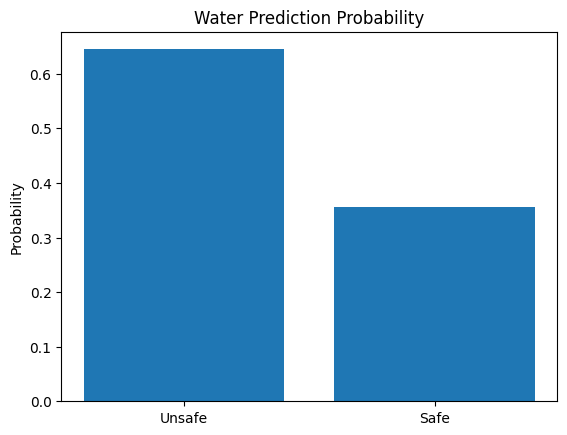

In [103]:
sample = x_test[0].reshape(1, -1)

prob = best_model.predict_proba(sample)[0]

labels = ["Unsafe", "Safe"]

plt.bar(labels, prob)
plt.title("Water Prediction Probability")
plt.ylabel("Probability")
plt.show()

In [104]:
import joblib

joblib.dump(best_model, "water_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel Saved Successfully!")


Model Saved Successfully!


In [105]:
from google.colab import files

files.download("water_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>